# 第二课：PyTorch 自动求导（Autograd）

## 为什么需要自动求导？

深度学习的核心是**梯度下降**：用损失函数对参数的梯度来更新参数。

手动计算梯度非常繁琐且容易出错，PyTorch 的 Autograd 机制可以**自动计算梯度**。

## 核心概念

| 概念 | 说明 |
|------|------|
| `requires_grad` | 标记张量是否需要计算梯度 |
| `grad` | 存储计算得到的梯度值 |
| `grad_fn` | 记录创建该张量的运算（计算图节点） |
| `backward()` | 反向传播，计算所有梯度 |
| 计算图 | 有向无环图，记录运算的依赖关系 |

In [2]:
import torch

## 1. 基本用法：标量求导

In [3]:
# 创建一个需要求导的张量
x = torch.tensor(3.0, requires_grad=True)
print("x =", x)
print("x.requires_grad =", x.requires_grad)
print("x.grad =", x.grad)  # 还没有计算梯度，所以是 None

x = tensor(3., requires_grad=True)
x.requires_grad = True
x.grad = None


In [4]:
# 前向计算：y = x^2
y = x ** 2
print("y = x^2 =", y)
print("y.grad_fn =", y.grad_fn)  # 记录了 y 是怎么来的（PowBackward）

y = x^2 = tensor(9., grad_fn=<PowBackward0>)
y.grad_fn = <PowBackward0 object at 0x000001587CA82200>


In [5]:
# 反向传播：计算 dy/dx
y.backward()

# dy/dx = 2x = 2 * 3 = 6
print("dy/dx =", x.grad)
print("验证：2 * x =", 2 * x.item())

dy/dx = tensor(6.)
验证：2 * x = 6.0


### 📐 数学原理

$y = x^2$

$\frac{dy}{dx} = 2x = 2 \times 3 = 6$ ✓

## 2. 复合函数求导（链式法则）

In [6]:
x = torch.tensor(2.0, requires_grad=True)

# 复合函数：z = (x - 1)^2 + 3
y = x - 1       # y = x - 1
z = y ** 2 + 3  # z = y^2 + 3

print(f"x = {x.item()}")
print(f"y = x - 1 = {y.item()}")
print(f"z = y^2 + 3 = {z.item()}")

# 反向传播
z.backward()

# dz/dx = dz/dy * dy/dx = 2y * 1 = 2(x-1) = 2(2-1) = 2
print(f"\ndz/dx = {x.grad}")
print(f"验证：2*(x-1) = {2 * (x.item() - 1)}")

x = 2.0
y = x - 1 = 1.0
z = y^2 + 3 = 4.0

dz/dx = 2.0
验证：2*(x-1) = 2.0


### 📐 链式法则

$z = (x-1)^2 + 3$

$\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} = 2y \cdot 1 = 2(x-1) = 2(2-1) = 2$ ✓

## 3. 向量和矩阵的求导

In [7]:
# 向量求导：注意 backward() 默认需要一个标量输出
# 对于向量输出，需要传入 gradient 参数

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 2

# y 是向量，不能直接 backward
# 方法1：对 y 求和得到标量
z = y.sum()
z.backward()

# dz/dx_i = 2*x_i
print("z = sum(x^2) 对 x 的梯度:", x.grad)
print("验证：2*x =", (2 * x).detach())

z = sum(x^2) 对 x 的梯度: tensor([2., 4., 6.])
验证：2*x = tensor([2., 4., 6.])


In [8]:
# 矩阵运算求导：模拟一个简单的线性层
W = torch.randn(2, 3, requires_grad=True)  # 权重矩阵
x = torch.randn(3, 1)                       # 输入向量（不需要梯度）
b = torch.randn(2, 1, requires_grad=True)   # 偏置

# 前向传播：y = Wx + b
y = W @ x + b
loss = y.sum()  # 简单的损失函数

# 反向传播
loss.backward()

print("W 的梯度形状:", W.grad.shape)  # 和 W 形状相同
print("b 的梯度形状:", b.grad.shape)  # 和 b 形状相同
print("x 的梯度:", x.grad)            # None，因为 requires_grad=False

W 的梯度形状: torch.Size([2, 3])
b 的梯度形状: torch.Size([2, 1])
x 的梯度: None


## 4. 计算图可视化

In [9]:
# 通过 grad_fn 追踪计算图
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

u = w * x     # u = wx
v = u + b     # v = wx + b
loss = v ** 2 # loss = (wx + b)^2

print("计算图追踪：")
print(f"  loss.grad_fn = {loss.grad_fn}")
print(f"  loss.grad_fn.next_functions = {loss.grad_fn.next_functions}")
print(f"  v.grad_fn = {v.grad_fn}")
print(f"  u.grad_fn = {u.grad_fn}")

# 计算图结构：
#   x ──┐
#        ├─ u = w*x ──┐
#   w ──┘              ├─ v = u+b ── loss = v^2
#                  b ──┘

计算图追踪：
  loss.grad_fn = <PowBackward0 object at 0x000001587C5E7EE0>
  loss.grad_fn.next_functions = ((<AddBackward0 object at 0x0000015848A58AC0>, 0),)
  v.grad_fn = <AddBackward0 object at 0x000001587C5E7EE0>
  u.grad_fn = <MulBackward0 object at 0x000001587C5E7EE0>


In [10]:
# 反向传播验证
loss.backward()

# loss = (wx + b)^2
# dloss/dw = 2(wx+b) * x = 2*(3*2+1)*2 = 28
# dloss/db = 2(wx+b) * 1 = 2*(3*2+1) = 14
# dloss/dx = 2(wx+b) * w = 2*(3*2+1)*3 = 42

print(f"dloss/dw = {w.grad}，验证：{2 * (w.item()*x.item()+b.item()) * x.item()}")
print(f"dloss/db = {b.grad}，验证：{2 * (w.item()*x.item()+b.item())}")
print(f"dloss/dx = {x.grad}，验证：{2 * (w.item()*x.item()+b.item()) * w.item()}")

dloss/dw = 28.0，验证：28.0
dloss/db = 14.0，验证：14.0
dloss/dx = 42.0，验证：42.0


## 5. 梯度累积问题

In [11]:
# ⚠️ 梯度是累积的！每次 backward() 会把梯度加到 .grad 上
x = torch.tensor(3.0, requires_grad=True)

y = x ** 2
y.backward()
print(f"第1次 backward 后，x.grad = {x.grad}")  # 6

# 如果不清零，再次 backward 会累积
y = x ** 2
y.backward()
print(f"第2次 backward 后，x.grad = {x.grad}")  # 12！不是6！

# 正确做法：每次迭代前清零梯度
x.grad.zero_()
y = x ** 2
y.backward()
print(f"清零后 backward，x.grad = {x.grad}")  # 6 ✓

第1次 backward 后，x.grad = 6.0
第2次 backward 后，x.grad = 12.0
清零后 backward，x.grad = 6.0


## 6. 控制梯度计算

In [12]:
# 方法1：torch.no_grad() — 推理时使用，不计算梯度，节省内存
x = torch.tensor(3.0, requires_grad=True)

with torch.no_grad():
    y = x ** 2
    print("no_grad 内：y.requires_grad =", y.requires_grad)  # False
    print("no_grad 内：y.grad_fn =", y.grad_fn)              # None

# 方法2：.detach() — 从计算图中分离张量
y2 = x ** 2
y2_detached = y2.detach()
print("\ndetach 后：y2_detached.requires_grad =", y2_detached.requires_grad)  # False
print("detach 后：y2_detached.grad_fn =", y2_detached.grad_fn)                # None

no_grad 内：y.requires_grad = False
no_grad 内：y.grad_fn = None

detach 后：y2_detached.requires_grad = False
detach 后：y2_detached.grad_fn = None


In [13]:
# 方法3：torch.enable_grad() — 在 no_grad 内强制开启
with torch.no_grad():
    with torch.enable_grad():
        y = x ** 2
        print("enable_grad 内：y.requires_grad =", y.requires_grad)  # True

enable_grad 内：y.requires_grad = True


In [14]:
# 方法4：@torch.no_grad() 装饰器 — 用于推理函数
@torch.no_grad()
def inference(model, x):
    return model(x)

print("装饰器方式同样有效")

装饰器方式同样有效


## 7. 实战：用 Autograd 实现梯度下降

In [15]:
# 用梯度下降求解：找到使 f(x) = (x-5)^2 最小的 x
# 答案显然是 x=5，让我们用 Autograd 来验证

x = torch.tensor(0.0, requires_grad=True)  # 初始值 x=0
lr = 0.1  # 学习率

print("梯度下降过程：")
print(f"初始: x = {x.item():.4f}")

for step in range(30):
    y = (x - 5) ** 2       # 前向：计算损失
    y.backward()            # 反向：计算梯度
    
    with torch.no_grad():
        x -= lr * x.grad    # 更新参数：x = x - lr * grad
        x.grad.zero_()      # 清零梯度！
    
    if step % 5 == 0 or step == 29:
        print(f"Step {step:2d}: x = {x.item():.4f}, loss = {(x.item()-5)**2:.6f}")

print(f"\n最终结果: x = {x.item():.4f}（理论值: 5.0）")

梯度下降过程：
初始: x = 0.0000
Step  0: x = 1.0000, loss = 16.000000
Step  5: x = 3.6893, loss = 1.717987
Step 10: x = 4.5705, loss = 0.184467
Step 15: x = 4.8593, loss = 0.019807
Step 20: x = 4.9539, loss = 0.002127
Step 25: x = 4.9849, loss = 0.000228
Step 29: x = 4.9938, loss = 0.000038

最终结果: x = 4.9938（理论值: 5.0）


### 🔍 代码解析

上面的代码展示了深度学习训练的核心循环：

```
for each step:
    1. 前向传播 → 计算损失
    2. 反向传播 → 计算梯度
    3. 更新参数 → x = x - lr * grad
    4. 清零梯度 → 准备下一次迭代
```

⚠️ 注意 `with torch.no_grad():` 包裹参数更新，因为更新操作不应该被记录到计算图中。

## 8. 多参数优化（模拟线性回归）

In [16]:
# 生成模拟数据：y = 3x + 1 + 噪声
torch.manual_seed(42)
x_data = torch.randn(100, 1)
y_data = 3 * x_data + 1 + 0.5 * torch.randn(100, 1)

# 初始化参数
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.1
losses = []

for step in range(100):
    # 前向传播
    y_pred = w * x_data + b
    loss = ((y_pred - y_data) ** 2).mean()  # MSE 损失
    losses.append(loss.item())
    
    # 反向传播
    loss.backward()
    
    # 更新参数
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

print(f"学习到的参数: w = {w.item():.4f}, b = {b.item():.4f}")
print(f"真实参数:     w = 3.0000, b = 1.0000")

学习到的参数: w = 3.0059, b = 1.0178
真实参数:     w = 3.0000, b = 1.0000


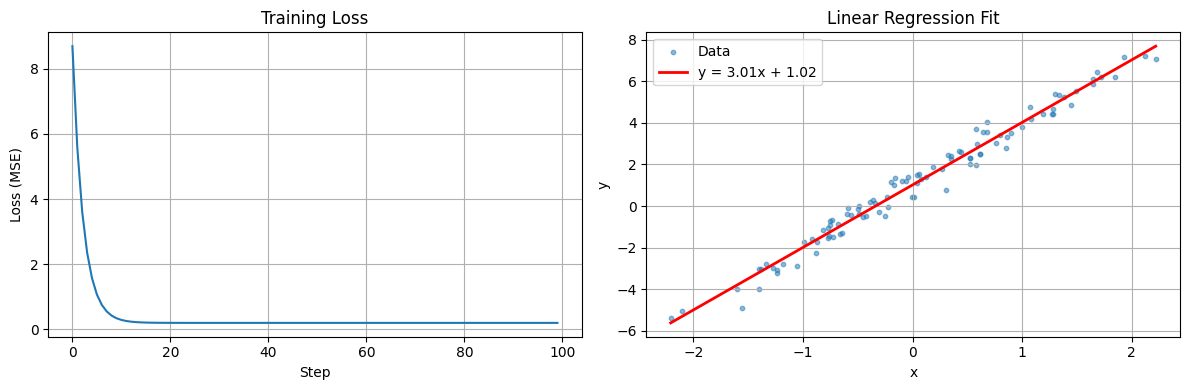

In [17]:
# 可视化训练过程
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(losses)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training Loss')
axes[0].grid(True)

# 拟合结果
axes[1].scatter(x_data.numpy(), y_data.numpy(), s=10, alpha=0.5, label='Data')
x_line = torch.linspace(x_data.min(), x_data.max(), 100).unsqueeze(1)
y_line = w.detach() * x_line + b.detach()
axes[1].plot(x_line.numpy(), y_line.numpy(), 'r-', linewidth=2, label=f'y = {w.item():.2f}x + {b.item():.2f}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Linear Regression Fit')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 9. 常见陷阱与最佳实践

In [18]:
# 陷阱1：忘记清零梯度
x = torch.tensor(2.0, requires_grad=True)

for i in range(3):
    y = x ** 2
    y.backward()
    print(f"Step {i}: x.grad = {x.grad} (期望值是4，但会累积！)")
    # 忘记写 x.grad.zero_()

Step 0: x.grad = 4.0 (期望值是4，但会累积！)
Step 1: x.grad = 8.0 (期望值是4，但会累积！)
Step 2: x.grad = 12.0 (期望值是4，但会累积！)


In [19]:
# 陷阱2：原地操作破坏计算图
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x * 2

try:
    y += 1  # 原地操作！会破坏计算图
    z = y.sum()
    z.backward()
except RuntimeError as e:
    print(f"错误: {e}")
    print("解决方法：用 y = y + 1 代替 y += 1")

In [20]:
# 陷阱3：item() vs 直接使用张量
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

# 如果只需要数值，用 .item() 避免内存泄漏
loss_val = y.item()   # ✓ 返回 Python 标量
loss_tensor = y       # ✗ 保留对计算图的引用

print(f".item() 类型: {type(loss_val)}")
print(f"张量类型: {type(loss_tensor)}")
print("记录 loss 时用 .item()，避免累积计算图导致内存泄漏")

.item() 类型: <class 'float'>
张量类型: <class 'torch.Tensor'>
记录 loss 时用 .item()，避免累积计算图导致内存泄漏


In [21]:
# 陷阱4：叶子节点 vs 非叶子节点
x = torch.tensor(2.0, requires_grad=True)  # 叶子节点
y = x ** 2                                   # 非叶子节点
z = y + 1                                    # 非叶子节点

print(f"x.is_leaf = {x.is_leaf}, x.grad_fn = {x.grad_fn}")
print(f"y.is_leaf = {y.is_leaf}, y.grad_fn = {y.grad_fn}")
print(f"z.is_leaf = {z.is_leaf}, z.grad_fn = {z.grad_fn}")

# 只有叶子节点的梯度会被保留，非叶子节点的梯度默认不保留
z.backward()
print(f"\nbackward 后：")
print(f"x.grad = {x.grad}  (叶子节点，梯度保留)")
print(f"y.grad = {y.grad}  (非叶子节点，梯度不保留)")

x.is_leaf = True, x.grad_fn = None
y.is_leaf = False, y.grad_fn = <PowBackward0 object at 0x000001580110F670>
z.is_leaf = False, z.grad_fn = <AddBackward0 object at 0x000001580110F670>

backward 后：
x.grad = 4.0  (叶子节点，梯度保留)
y.grad = None  (非叶子节点，梯度不保留)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29204\1515434189.py:14: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:499.)
  print(f"y.grad = {y.grad}  (非叶子节点，梯度不保留)")


---
## 📝 第二课总结

| 知识点 | 要点 |
|--------|------|
| `requires_grad=True` | 标记需要求导的张量 |
| `backward()` | 反向传播，自动计算梯度 |
| `grad_fn` | 记录运算历史，构成计算图 |
| 链式法则 | Autograd 自动应用链式法则计算复合函数梯度 |
| 梯度累积 | 每次 backward 梯度会累加，必须手动清零 |
| `torch.no_grad()` | 推理时关闭梯度计算，节省内存 |
| `.detach()` | 从计算图分离张量 |
| `.item()` | 获取标量值，避免内存泄漏 |
| 叶子节点 | 只有叶子节点的梯度会被保留 |

### 🔑 核心训练循环
```
for step in range(epochs):
    loss = 前向传播(x)        # 1. 计算损失
    loss.backward()           # 2. 反向传播求梯度
    with torch.no_grad():
        参数 -= lr * 参数.grad  # 3. 更新参数
        参数.grad.zero_()      # 4. 清零梯度
```

下一课我们将学习如何用 `nn.Module` 更优雅地实现这个训练循环！